In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)
RANDOM_STATE = 45

In [8]:
train_df = pd.read_csv("../DataSet/processed/telco_churn_train.csv")
validation_df = pd.read_csv("../DataSet/processed/telco_churn_validation.csv")

X_train = train_df.drop(columns="Churn")
y_train = train_df["Churn"]

X_validation = validation_df.drop(columns="Churn")
y_validation = validation_df["Churn"]
def evaluate_model(name, model, X, y):
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)[:, 1]

    print(f"{name} - Validation Results")
    print("-" * 45)
    print(
        classification_report(
            y,
            predictions,
            target_names=["Retained", "Churned"],
            zero_division=0
        )
    )

    ConfusionMatrixDisplay.from_predictions(
        y,
        predictions,
        display_labels=["Retained", "Churned"],
        cmap="Blues"
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return {
        "Model": name,
        "Accuracy": accuracy_score(y, predictions),
        "Precision": precision_score(y, predictions, zero_division=0),
        "Recall": recall_score(y, predictions, zero_division=0),
        "F1": f1_score(y, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y, probabilities)
    }

Dummy Baseline - Validation Results
---------------------------------------------
              precision    recall  f1-score   support

    Retained       0.73      1.00      0.85       774
     Churned       0.00      0.00      0.00       281

    accuracy                           0.73      1055
   macro avg       0.37      0.50      0.42      1055
weighted avg       0.54      0.73      0.62      1055



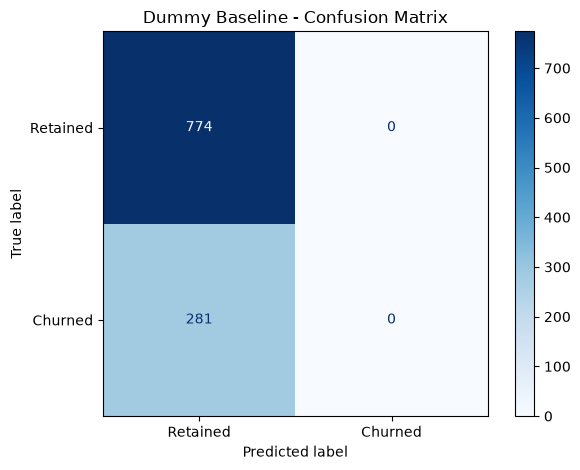

In [9]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train, y_train)

dummy_result = evaluate_model(
    "Dummy Baseline",
    dummy_model,
    X_validation,
    y_validation
)

Logistic Regression - Validation Results
---------------------------------------------
              precision    recall  f1-score   support

    Retained       0.84      0.88      0.86       774
     Churned       0.61      0.53      0.57       281

    accuracy                           0.78      1055
   macro avg       0.72      0.70      0.71      1055
weighted avg       0.78      0.78      0.78      1055



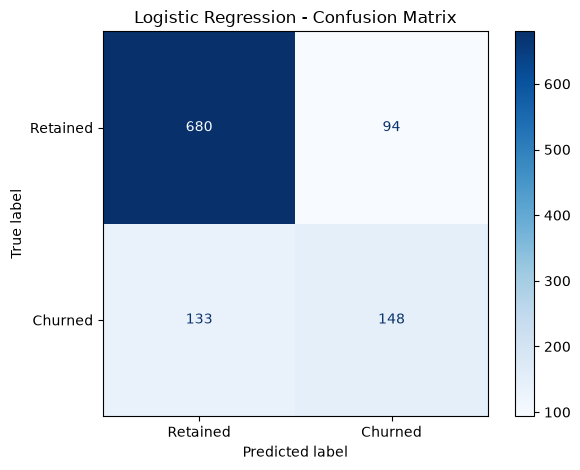

In [13]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

X_train_processed = pd.get_dummies(
    X_train,
    drop_first=True
)

X_validation_processed = pd.get_dummies(
    X_validation,
    drop_first=True
)

X_validation_processed = X_validation_processed.reindex(
    columns=X_train_processed.columns,
    fill_value=0
)

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

logistic_model.fit(
    X_train_processed,
    y_train
)

logistic_result = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_validation_processed,
    y_validation
)

Decision Tree - Validation Results
---------------------------------------------
              precision    recall  f1-score   support

    Retained       0.81      0.90      0.85       774
     Churned       0.59      0.40      0.48       281

    accuracy                           0.77      1055
   macro avg       0.70      0.65      0.67      1055
weighted avg       0.75      0.77      0.75      1055



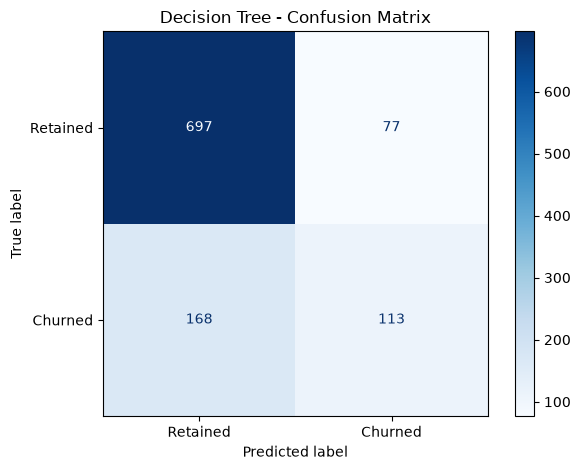

In [14]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=RANDOM_STATE
)

decision_tree_model.fit(
    X_train_processed,
    y_train
)

decision_tree_result = evaluate_model(
    "Decision Tree",
    decision_tree_model,
    X_validation_processed,
    y_validation
)